In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
os.chdir("..")

In [3]:
gdf = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")

In [4]:
columns_to_observe = [column for column in gdf.columns if column.startswith("average_time")]

In [5]:
for column in columns_to_observe:
    gdf[column] = gdf[column].apply(lambda x: np.mean(list(x.values())))

In [6]:
gdf.head(2)

,geometry,average_time_bike_1,average_time_bike_2,average_time_bike_20,average_time_bike_morning_vuln1_1,average_time_bike_morning_vuln1_2,average_time_bike_morning_vuln1_20,average_time_bike_morning_vuln2_1,average_time_bike_morning_vuln2_2,average_time_bike_morning_vuln2_20,...,average_time_walk_PT_evening_vuln2_20,average_time_walk_PT_evening_vuln3_1,average_time_walk_PT_evening_vuln3_2,average_time_walk_PT_evening_vuln3_20,average_time_walk_PT_evening_vuln4_1,average_time_walk_PT_evening_vuln4_2,average_time_walk_PT_evening_vuln4_20,average_time_walk_PT_evening_vuln5_1,average_time_walk_PT_evening_vuln5_2,average_time_walk_PT_evening_vuln5_20
0,"POLYGON ((638273.51 5523017.185, 638100.305 55...",6.661755,7.194323,10.657284,7.856956,8.342240,13.285350,8.983680,9.418548,15.428905,...,51.806087,38.378771,39.753045,56.483910,41.338498,42.968262,60.467604,43.528243,45.444253,64.016070
1,"POLYGON ((638619.92 5523017.185, 638446.715 55...",7.285188,7.817755,11.271471,9.049177,9.534462,14.477571,10.582798,11.029229,17.114304,...,55.517706,43.304585,44.678859,61.409724,47.478507,49.108271,66.607614,50.882447,52.798457,71.370274


In [7]:
gdf_mean = gdf.mean(axis=0, numeric_only=True)


In [8]:
all_columns_to_observe = columns_to_observe

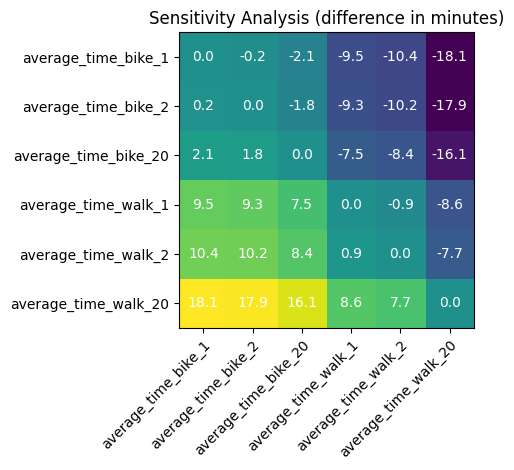

In [9]:
# columns_to_observe = columns_to_observe[0:10]
columns_to_observe = [column for column in all_columns_to_observe if len(column) < 21]

rows = [[gdf_mean[column_row] - gdf_mean[column_column] for column_column in columns_to_observe] for column_row in columns_to_observe]
rows = np.array(rows)

fig, ax = plt.subplots()
im = ax.imshow(rows)

for i in range(len(columns_to_observe)):
    for j in range(len(columns_to_observe)):
        text = ax.text(j, i, round(rows[i, j], 1),
                       ha="center", va="center", color="w")

ax.set_xticks(range(len(columns_to_observe)), labels=columns_to_observe,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(columns_to_observe)), labels=columns_to_observe)

ax.set_title("Sensitivity Analysis (difference in minutes)")
fig.tight_layout()

plt.show()

In [10]:
# https://matplotlib.org/stable/gallery/color/colormap_reference.html

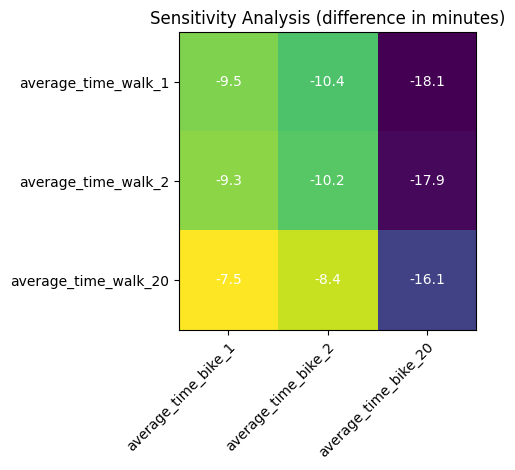

In [11]:
# columns_to_observe = columns_to_observe[0:10]
columns_to_observe = [column for column in all_columns_to_observe if len(column) < 21]
columns1 = [column for column in all_columns_to_observe if column.startswith("average_time_bike") and len(column) < 21]
columns2 = [column for column in all_columns_to_observe if column.startswith("average_time_walk") and len(column) < 21]

rows = [[gdf_mean[column_row] - gdf_mean[column_column] for column_column in columns2] for column_row in columns1]
rows = np.array(rows)

fig, ax = plt.subplots()
im = ax.imshow(rows)

for i in range(len(columns1)):
    for j in range(len(columns2)):
        text = ax.text(j, i, round(rows[i, j], 1),
                       ha="center", va="center", color="w")

ax.set_xticks(range(len(columns1)), labels=columns1,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(columns2)), labels=columns2)

ax.set_title("Sensitivity Analysis (difference in minutes)")
fig.tight_layout()

plt.show()

# Sensitivity Analysis of $n$

In [12]:
g = ['average_time_walk',
 'average_time_bike',
 'average_time_walk_PT',
 'average_time_walk_evening_vuln4',
 'average_time_bike_morning_vuln2',
 'average_time_walk_PT_morning_vuln2',
 'average_time_walk_PT_evening_vuln5',
 'average_time_bike_evening_vuln5',
 'average_time_walk_afternoon_vuln3',
 'average_time_walk_evening_vuln1']

In [13]:
df_sensitivity_n = pd.DataFrame({"name":g, "1": [gdf_mean[index + "_1"] for index in g], "2": [gdf_mean[index + "_2"] for index in g], "20": [gdf_mean[index + "_20"] for index in g]})
df_sensitivity_n

,name,1,2,20
0,average_time_walk,12.400250,13.308470,21.014032
1,average_time_bike,2.888579,3.102387,4.947961
2,average_time_walk_PT,11.588305,12.372955,17.686067
3,average_time_walk_evening_vuln4,36.307939,39.202137,61.071061
4,average_time_bike_morning_vuln2,6.254334,6.769622,11.100398
5,average_time_walk_PT_morning_vuln2,23.987074,25.701868,36.341920
6,average_time_walk_PT_evening_vuln5,36.860793,39.344901,52.629526
7,average_time_bike_evening_vuln5,9.750809,10.537357,16.398554
8,average_time_walk_afternoon_vuln3,33.749954,36.656847,59.956550
9,average_time_walk_evening_vuln1,18.878878,20.354381,32.194764


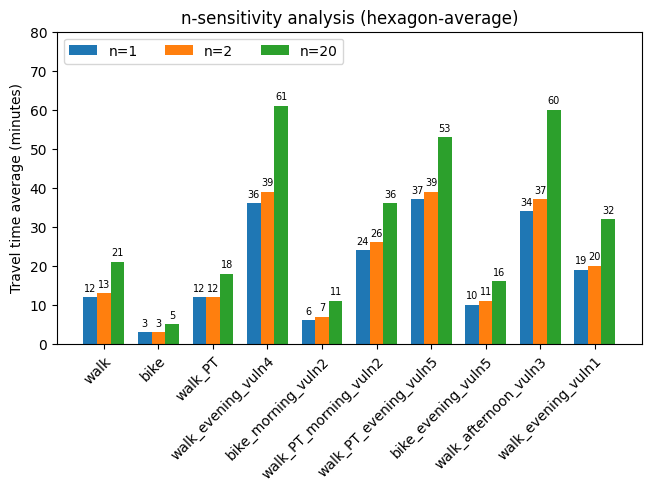

In [14]:
configurations = df_sensitivity_n["name"]
n_s = {
    'n=1': df_sensitivity_n["1"].round(),
    'n=2': df_sensitivity_n["2"].round(),
    'n=20': df_sensitivity_n["20"].round()
}

x = np.arange(len(configurations)) * 2  # the label locations, spaced to fit wider bars
width = 0.5  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in n_s.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fontsize=7)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Travel time average (minutes)')
ax.set_title('n-sensitivity analysis (hexagon-average)')
ax.set_xticks(x + width, [configuration.replace("average_time_", "") for configuration in configurations], rotation=45, ha="right", rotation_mode="anchor")
ax.legend(loc='upper left', ncols=3)
max_height = max(max(measurement) for measurement in n_s.values())
ax.set_ylim(0, 80)

plt.show()

In [15]:
gdf_population = gpd.read_parquet("data/evaluation/evaluation_raster_population.parquet")

In [16]:
gdf_myhexagon = gdf.merge(gdf_population, left_index=True, right_index=True)
gdf_myhexagon = gdf_myhexagon.rename(columns={"value_result": "population"})
gdf_myhexagon["population"] = gdf_myhexagon["population"].fillna(0)

In [17]:
weighted_mean = {}
for column in gdf_myhexagon.columns:
    if not column.startswith("average_time"):
        continue
    weighted_mean[column] = (gdf_myhexagon[column] * gdf_myhexagon["population"]).sum() / gdf_myhexagon["population"].sum()

In [18]:
df_sensitivity_n_weighted = pd.DataFrame({"name":g, "1": [weighted_mean[index + "_1"] for index in g], "2": [weighted_mean[index + "_2"] for index in g], "20": [weighted_mean[index + "_20"] for index in g]})

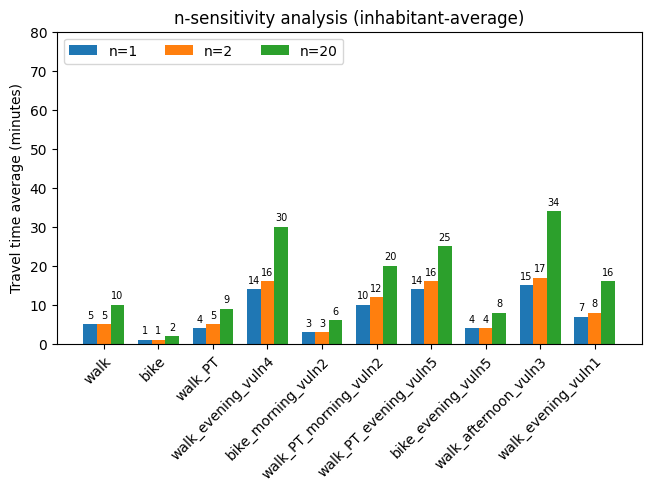

In [19]:
configurations = df_sensitivity_n_weighted["name"]
n_s = {
    'n=1': df_sensitivity_n_weighted["1"].round(),
    'n=2': df_sensitivity_n_weighted["2"].round(),
    'n=20': df_sensitivity_n_weighted["20"].round()
}

x = np.arange(len(configurations)) * 2  # the label locations, spaced to fit wider bars
width = 0.5  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in n_s.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fontsize=7)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Travel time average (minutes)')
ax.set_title('n-sensitivity analysis (inhabitant-average)')
ax.set_xticks(x + width, [configuration.replace("average_time_", "") for configuration in configurations], rotation=45, ha="right", rotation_mode="anchor")
ax.legend(loc='upper left', ncols=3)
max_height = max(max(measurement) for measurement in n_s.values())
ax.set_ylim(0, 80)

plt.show()

# Walking speed

In [20]:
result_obj = {
    "1.14": {
        "average_time_walk_20": np.float64(25.12963256178185),
        "average_time_walk_PT_20": np.float64(20.79076426144327),
        "average_time_walk_morning_vuln3_20": np.float64(83.76534365579671),
        # "average_time_walk_PT_evening_vuln5_1": np.float64(79.78299370864522),
        "average_time_walk_PT_evening_vuln5_20": np.float64(107.88342169456637),
    },
    "1.24": {
        "average_time_walk_20": np.float64(23.059937096769673),
        "average_time_walk_PT_20": np.float64(19.3575631485018),
        "average_time_walk_morning_vuln3_20": np.float64(76.87993189319367),
        # "average_time_walk_PT_evening_vuln5_1": np.float64(73.52245856553381),
        "average_time_walk_PT_evening_vuln5_20": np.float64(100.18663345026118),
    },
    "1.34": {
        "average_time_walk_20": np.float64(21.30640551034699),
        "average_time_walk_PT_20": np.float64(18.121407420420592),
        "average_time_walk_morning_vuln3_20": np.float64(71.04425677981342),
        # "average_time_walk_PT_evening_vuln5_1": np.float64(68.19184116073835),
        "average_time_walk_PT_evening_vuln5_20": np.float64(91.37578311232723),
    },
    "1.44": {
        "average_time_walk_20": np.float64(19.80142584909846),
        "average_time_walk_PT_20": np.float64(17.045211498142116),
        "average_time_walk_morning_vuln3_20": np.float64(66.03417595482772),
        # "average_time_walk_PT_evening_vuln5_1": np.float64(63.59793195481232),
        "average_time_walk_PT_evening_vuln5_20": np.float64(87.80835649463555),
    },
    "1.54": {
        "average_time_walk_20": np.float64(18.49559151184759),
        "average_time_walk_PT_20": np.float64(16.099743519619167),
        "average_time_walk_morning_vuln3_20": np.float64(61.68580171592331),
        # "average_time_walk_PT_evening_vuln5_1": np.float64(59.5957378547592),
        "average_time_walk_PT_evening_vuln5_20": np.float64(80.77428573530112),
    },
}

df_walking = pd.DataFrame(result_obj)
df_walking

,1.14,1.24,1.34,1.44,1.54
average_time_walk_20,25.129633,23.059937,21.306406,19.801426,18.495592
average_time_walk_PT_20,20.790764,19.357563,18.121407,17.045211,16.099744
average_time_walk_morning_vuln3_20,83.765344,76.879932,71.044257,66.034176,61.685802
average_time_walk_PT_evening_vuln5_20,107.883422,100.186633,91.375783,87.808356,80.774286


In [21]:
list(df_walking.loc["average_time_walk_20"])

[25.12963256178185,
 23.059937096769673,
 21.30640551034699,
 19.80142584909846,
 18.49559151184759]

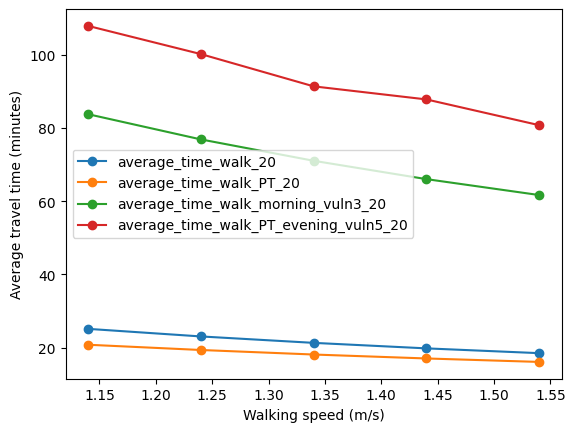

In [22]:
x = np.arange(1.14, 1.54, 0.1)

for configuration in df_walking.index:
    y = list(df_walking.loc[configuration])
    plt.plot(x, y, 'o-', label=configuration)

plt.xlabel('Walking speed (m/s)')
plt.ylabel('Average travel time (minutes)')
plt.legend()
plt.show()


# Group Differentiation

In [23]:
gdf_over_65 = gpd.read_parquet("data/evaluation/evaluation_raster_percentage_of_people_over_65.parquet")
gdf_under_18 = gpd.read_parquet("data/evaluation/evaluation_raster_percentage_of_people_under_18.parquet")
gdf_population = gpd.read_parquet("data/evaluation/evaluation_raster_population.parquet")

In [24]:
gdf_init = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")

In [25]:
gdf_init = gdf_init[["geometry", "average_time_bike_noon_vuln1_20", "average_time_walk_PT_noon_vuln4_20"]]

In [26]:
gdf_init.head(1)

,geometry,average_time_bike_noon_vuln1_20,average_time_walk_PT_noon_vuln4_20
0,"POLYGON ((638273.51 5523017.185, 638100.305 55...","{'culture': 10.70651141291147, 'education': 22...","{'culture': 61.39766018716735, 'education': 83..."


In [27]:
gdf_all = pd.concat([gdf_init, gdf_over_65[["value_result"]].rename(columns={"value_result": "percentage_over_65"}), gdf_under_18[["value_result"]].rename(columns={"value_result": "percentage_under_18"}), gdf_population[["value_result"]].rename(columns={"value_result": "population"})], axis=1)
gdf_all["under_18"] = (gdf_all["percentage_under_18"] / 100 * gdf_all["population"]).fillna(0)
gdf_all["over_65"] = (gdf_all["percentage_over_65"] / 100 * gdf_all["population"]).fillna(0)
gdf_all["percentage_between_18_and_65"] = (100 - gdf_all["percentage_over_65"] - gdf_all["percentage_under_18"]).clip(0)
gdf_all["between_18_and_65"] = (gdf_all["percentage_between_18_and_65"] / 100 * gdf_all["population"]).fillna(0)
# gdf_all = gdf_all.drop(columns=["percentage_over_65", "percentage_under_18", "percentage_between_18_and_65"])
gdf_all["population"] = gdf_all["population"].fillna(0)
gdf_all.head(1)

,geometry,average_time_bike_noon_vuln1_20,average_time_walk_PT_noon_vuln4_20,percentage_over_65,percentage_under_18,population,under_18,over_65,percentage_between_18_and_65,between_18_and_65
0,"POLYGON ((638273.51 5523017.185, 638100.305 55...","{'culture': 10.70651141291147, 'education': 22...","{'culture': 61.39766018716735, 'education': 83...",NaN,NaN,0.0,0.0,0.0,NaN,0.0


In [28]:
result = {}

def get_values(gdf, category: str, category_preferentiation: dict):
    result_series = gdf[category].apply(lambda x: sum([value * category_preferentiation.get(key, 1) for key, value in x.items()]) / (sum(category_preferentiation.values()) + len(x) - len(category_preferentiation)))

    return result_series.mean(), result_series.median(), result_series.std()

for category, category_preferentiation in zip(["average_time_bike_noon_vuln1_20", "average_time_walk_PT_noon_vuln4_20"], [{"culture": 0.5, "healthcare": 0.5, "restaurant": 0, "services": 0, "supplies": 0.5}, {"education": 0, "physical": 0.5, "outdoor": 0, "transport": 0.5}]):
    gdf_all[f"{category}_category_weight"] = gdf_all[category].apply(lambda x: sum([value * category_preferentiation.get(key, 1) for key, value in x.items()]) / (sum(category_preferentiation.values()) + len(x) - len(category_preferentiation)))

In [29]:
gdf_all.head(1)

,geometry,average_time_bike_noon_vuln1_20,average_time_walk_PT_noon_vuln4_20,percentage_over_65,percentage_under_18,population,under_18,over_65,percentage_between_18_and_65,between_18_and_65,average_time_bike_noon_vuln1_20_category_weight,average_time_walk_PT_noon_vuln4_20_category_weight
0,"POLYGON ((638273.51 5523017.185, 638100.305 55...","{'culture': 10.70651141291147, 'education': 22...","{'culture': 61.39766018716735, 'education': 83...",NaN,NaN,0.0,0.0,0.0,NaN,0.0,13.137639,66.089542


In [30]:
result = {}
for configuration in ["average_time_bike_noon_vuln1_20_category_weight", "average_time_walk_PT_noon_vuln4_20_category_weight"]:
    for weight in ["under_18", "over_65", "between_18_and_65", "population"]:
        average = np.average(gdf_all[configuration], weights=gdf_all[weight])
        variance = np.average((gdf_all[configuration] - average)**2, weights=gdf_all[weight])
        std = np.sqrt(variance)
        median = np.percentile(gdf_all[configuration], 50, weights=gdf_all[weight], method="inverted_cdf")
        percentage_under_15_minutes = gdf_all.apply(lambda row: row[weight] if row[configuration] < 15 else 0, axis=1).sum() / gdf_all[weight].sum() * 100

        result[(configuration, weight)] = (average, std, median, percentage_under_15_minutes)

print(result)

{('average_time_bike_noon_vuln1_20_category_weight', 'under_18'): (np.float64(4.904502337007075), np.float64(2.6478738775401673), array(4.61101408), np.float64(98.7871203134064)), ('average_time_bike_noon_vuln1_20_category_weight', 'over_65'): (np.float64(4.541107027128318), np.float64(2.7676662182931815), array(3.92487073), np.float64(98.55753524484518)), ('average_time_bike_noon_vuln1_20_category_weight', 'between_18_and_65'): (np.float64(4.2777021831674125), np.float64(2.4353759001580526), array(3.86737201), np.float64(98.95127039725128)), ('average_time_bike_noon_vuln1_20_category_weight', 'population'): (np.float64(4.572988785451108), np.float64(2.696006210990535), array(4.03171677), np.float64(98.77981790655791)), ('average_time_walk_PT_noon_vuln4_20_category_weight', 'under_18'): (np.float64(35.57881107346081), np.float64(17.108805238186186), array(33.77767264), np.float64(4.726277722405749)), ('average_time_walk_PT_noon_vuln4_20_category_weight', 'over_65'): (np.float64(32.9988

In [31]:
df_evaluation_age = pd.DataFrame(result, index=["average_time", "standard_deviation", "median", "percentage_under_15_minutes"])
df_evaluation_age

average_time_bike_noon_vuln1_20_category_weight  \
                                                                   under_18   
average_time                                                       4.904502   
standard_deviation                                                 2.647874   
median                                                    4.611014084751961   
percentage_under_15_minutes                                        98.78712   

                                                                    \
                                        over_65  between_18_and_65   
average_time                           4.541107           4.277702   
standard_deviation                     2.767666           2.435376   
median                       3.9248707272725665  3.867372010532008   
percentage_under_15_minutes           98.557535           98.95127   

                                                \
                                    population   
average_time                          4.572989   
standard_deviation                    2.696006   
median                       4.031716771008932   
percentage_under_15_minutes          98.779818   

                            average_time_walk_PT_noon_vuln4_20_category_weight  \
                                                                      under_18   
average_time                                                         35.578811   
standard_deviation                                                   17.108805   
median                                                       33.77767263580768   
percentage_under_15_minutes                                           4.726278   

                                                                   \
                                        over_65 between_18_and_65   
average_time                          32.998859         32.035133   
standard_deviation                    16.091465         15.186042   
median                       31.377843662316668    31.37235222247   
percentage_under_15_minutes            5.125834          7.623629   

                                                
                                    population  
average_time                         33.842946  
standard_deviation                   16.894955  
median                       31.51486687695216  
percentage_under_15_minutes           6.233215

In [32]:
df_evaluation_age.T.loc["average_time_bike_noon_vuln1_20_category_weight"].T

,under_18,over_65,between_18_and_65,population
average_time,4.904502,4.541107,4.277702,4.572989
standard_deviation,2.647874,2.767666,2.435376,2.696006
median,4.611014084751961,3.9248707272725665,3.867372010532008,4.031716771008932
percentage_under_15_minutes,98.78712,98.557535,98.95127,98.779818


In [33]:
df_evaluation_age.T.loc["average_time_walk_PT_noon_vuln4_20_category_weight"].T

,under_18,over_65,between_18_and_65,population
average_time,35.578811,32.998859,32.035133,33.842946
standard_deviation,17.108805,16.091465,15.186042,16.894955
median,33.77767263580768,31.377843662316668,31.37235222247,31.51486687695216
percentage_under_15_minutes,4.726278,5.125834,7.623629,6.233215


### Population distribution

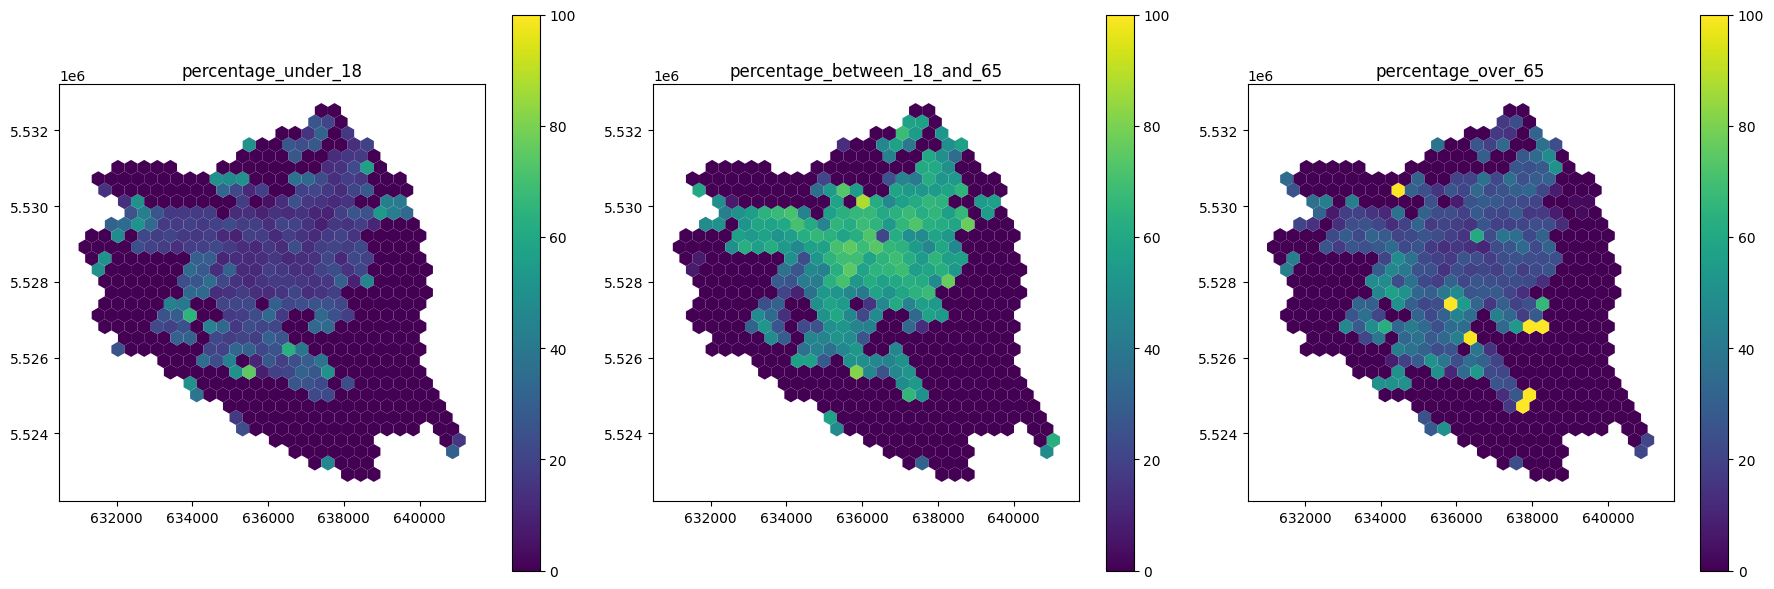

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, ["percentage_under_18", "percentage_between_18_and_65", "percentage_over_65"]):
    gdf_all[col] = gdf_all[col].fillna(0)
    gdf_all.plot(column=col, legend=True, ax=ax, vmin=0, vmax=100)

    ax.set_title(col)

plt.tight_layout()
plt.show()

### Foreigners

In [35]:
configurations = [
    "average_time_walk_morning_vuln4_1",
    "average_time_walk_PT_2",
    "average_time_walk_PT_evening_vuln1_20",
    "average_time_bike_afternoon_vuln5_1",
    "average_time_bike_morning_vuln4_2",
    "average_time_walk_PT_noon_vuln2_20",
]

In [36]:
gdf_foreigners = gpd.read_parquet("data/evaluation/evaluation_raster_percentage_of_foreigners.parquet")

gdf_cat = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")
gdf_cat = gdf_cat[["geometry"] + configurations]
gdf_cat = pd.concat([gdf_cat, gdf_population[["value_result"]].rename(columns={"value_result": "population"}), gdf_foreigners[["value_result"]].rename(columns={"value_result": "percentage_of_foreigners"})], axis=1)
gdf_cat["population"] = gdf_cat["population"].fillna(0)
gdf_cat["percentage_of_foreigners"] = gdf_cat["percentage_of_foreigners"].fillna(0)
gdf_cat["foreigners"] = gdf_cat["percentage_of_foreigners"] / 100 * gdf_cat["population"]

In [37]:
result = {}

for configuration in configurations:
    gdf_cat[configuration] = gdf_cat[configuration].apply(lambda x: np.mean(list(x.values())))
    for weight in ["population", "foreigners"]:
        average = np.average(gdf_cat[configuration], weights=gdf_cat[weight])
        variance = np.average((gdf_cat[configuration] - average)**2, weights=gdf_cat[weight])
        std = np.sqrt(variance)
        median = np.percentile(gdf_cat[configuration], 50, weights=gdf_cat[weight], method="inverted_cdf")
        percentage_under_15_minutes = gdf_cat.apply(lambda row: row[weight] if row[configuration] < 15 else 0, axis=1).sum() / gdf_cat[weight].sum() * 100

        result[(configuration, weight)] = (average, std, median, percentage_under_15_minutes)

result

{('average_time_walk_morning_vuln4_1',
  'population'): (np.float64(17.99188255117747), np.float64(19.30326215572645), array(13.900713), np.float64(58.75814833030132)),
 ('average_time_walk_morning_vuln4_1',
  'foreigners'): (np.float64(17.871731220245945), np.float64(16.893751345001657), array(14.48118147), np.float64(62.63666823299652)),
 ('average_time_walk_PT_2', 'population'): (np.float64(4.872220356638973),
  np.float64(4.282749391571852),
  array(3.92942524),
  np.float64(97.53175382957345)),
 ('average_time_walk_PT_2', 'foreigners'): (np.float64(5.157956368390365),
  np.float64(5.2042727291003015),
  array(4.19148145),
  np.float64(97.65126003709092)),
 ('average_time_walk_PT_evening_vuln1_20',
  'population'): (np.float64(12.662173547271818), np.float64(7.6337140345354735), array(11.04890292), np.float64(81.5608294585692)),
 ('average_time_walk_PT_evening_vuln1_20',
  'foreigners'): (np.float64(13.611366844210254), np.float64(8.084456827887605), array(14.05218095), np.float64(

In [38]:
df_foreigner_evaluation = pd.DataFrame(result, index=["average_time", "standard_deviation", "median", "percentage_under_15_minutes"]).T.reset_index(names=["configuration", "group"])
df_foreigner_evaluation

,configuration,group,average_time,standard_deviation,median,percentage_under_15_minutes
0,average_time_walk_morning_vuln4_1,population,17.991883,19.303262,13.900713002510729,58.758148
1,average_time_walk_morning_vuln4_1,foreigners,17.871731,16.893751,14.481181472845707,62.636668
2,average_time_walk_PT_2,population,4.87222,4.282749,3.929425244480803,97.531754
3,average_time_walk_PT_2,foreigners,5.157956,5.204273,4.1914814546915515,97.65126
4,average_time_walk_PT_evening_vuln1_20,population,12.662174,7.633714,11.04890292412697,81.560829
5,average_time_walk_PT_evening_vuln1_20,foreigners,13.611367,8.084457,14.052180947541698,85.058613
6,average_time_bike_afternoon_vuln5_1,population,5.166721,5.279958,4.152434946460368,96.571684
7,average_time_bike_afternoon_vuln5_1,foreigners,5.097405,4.522466,4.272616108911119,97.46962
8,average_time_bike_morning_vuln4_2,population,4.780335,4.600602,3.806103468501121,96.862101
9,average_time_bike_morning_vuln4_2,foreigners,4.957276,3.976753,4.968367805226011,97.658861


In [39]:
df_foreigner_by_group = df_foreigner_evaluation.groupby("group").agg({"average_time": list, "standard_deviation": list, "median": list, "percentage_under_15_minutes": list})
df_foreigner_by_group

,average_time,standard_deviation,median,percentage_under_15_minutes
group,,,,
foreigners,"[17.871731220245945, 5.157956368390365, 13.611...","[16.893751345001657, 5.2042727291003015, 8.084...","[14.481181472845707, 4.1914814546915515, 14.05...","[62.63666823299652, 97.65126003709092, 85.0586..."
population,"[17.99188255117747, 4.872220356638973, 12.6621...","[19.30326215572645, 4.282749391571852, 7.63371...","[13.900713002510729, 3.929425244480803, 11.048...","[58.75814833030132, 97.53175382957345, 81.5608..."


In [40]:
dict(df_foreigner_by_group["average_time"])

{'foreigners': [np.float64(17.871731220245945),
  np.float64(5.157956368390365),
  np.float64(13.611366844210254),
  np.float64(5.097405477907721),
  np.float64(4.957276418505635),
  np.float64(23.486863327323004)],
 'population': [np.float64(17.99188255117747),
  np.float64(4.872220356638973),
  np.float64(12.662173547271818),
  np.float64(5.166720670126216),
  np.float64(4.780334944253031),
  np.float64(21.684591864570013)]}

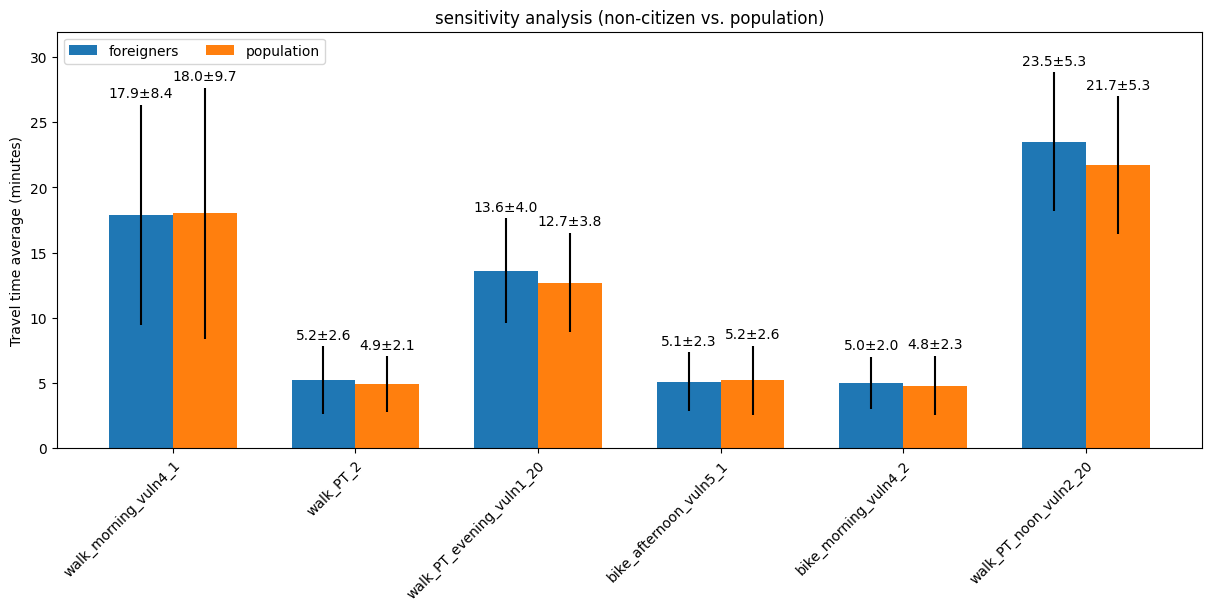

In [41]:
n_s = dict(df_foreigner_by_group["average_time"])
standard_deviations = dict(df_foreigner_by_group["standard_deviation"])

x = np.arange(len(configurations)) * 2  # the label locations, spaced to fit wider bars
width = 0.7  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout="constrained", figsize=(12, 6))


max_value = 0

for attribute, measurement in n_s.items():
    measurement = np.round(measurement, 1)
    y_errs = np.array(standard_deviations.get(attribute)) / 2

    max_value = max(max_value, max(measurement) + max(y_errs))
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, yerr=y_errs)
    ax.bar_label(
        rects,
        labels=[f"{val:.1f}±{err:.1f}" for val, err in zip(measurement, y_errs)],
        padding=3,
        # fontsize=10,
    )
    # ax.bar_label(rects, padding=-100, fontsize=7)
    # ax.bar_label(rects, label_type="center")
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel("Travel time average (minutes)")
ax.set_title("sensitivity analysis (non-citizen vs. population)")
ax.set_xticks(
    x + width / 2,
    [configuration.replace("average_time_", "") for configuration in configurations],
    rotation=45,
    ha="right",
    rotation_mode="anchor",
)
ax.legend(loc="upper left", ncols=2)
ax.set_ylim(0, max_value)

plt.show()

# Category with most influence

In [42]:
gdf_cat = gpd.read_parquet("results/hexagon_grid_bamberg.parquet")
gdf_cat = gdf_cat[["geometry", "average_time_walk_1", "average_time_walk_2", "average_time_walk_20"]]
gdf_cat = pd.concat([gdf_cat, gdf_population[["value_result"]].rename(columns={"value_result": "population"})], axis=1)
gdf_cat["population"] = gdf_cat["population"].fillna(0)

In [43]:
category_preferentiation_init = {"culture": 1, "education": 1, "healthcare": 1, "outdoor": 1, "physical": 1, "restaurant": 1, "services": 1, "supplies": 1, "transport": 1}

for configuration in ["average_time_walk_1", "average_time_walk_2", "average_time_walk_20"]:
    for category in category_preferentiation_init.keys():
        category_preferentiation = category_preferentiation_init.copy()
        category_preferentiation[category] = 0
        gdf_cat[f"{configuration}_without_{category}"] = gdf_cat[configuration].apply(lambda x: sum([value * category_preferentiation.get(key, 1) for key, value in x.items()]) / (sum(category_preferentiation.values()) + len(x) - len(category_preferentiation)))

In [44]:
columns = [f"{configuration}_without_{category}" for configuration in ["average_time_walk_1", "average_time_walk_2", "average_time_walk_20"] for category in category_preferentiation_init.keys()]
configurations = ["average_time_walk_1", "average_time_walk_2", "average_time_walk_20"]

categories = list(category_preferentiation_init.keys())


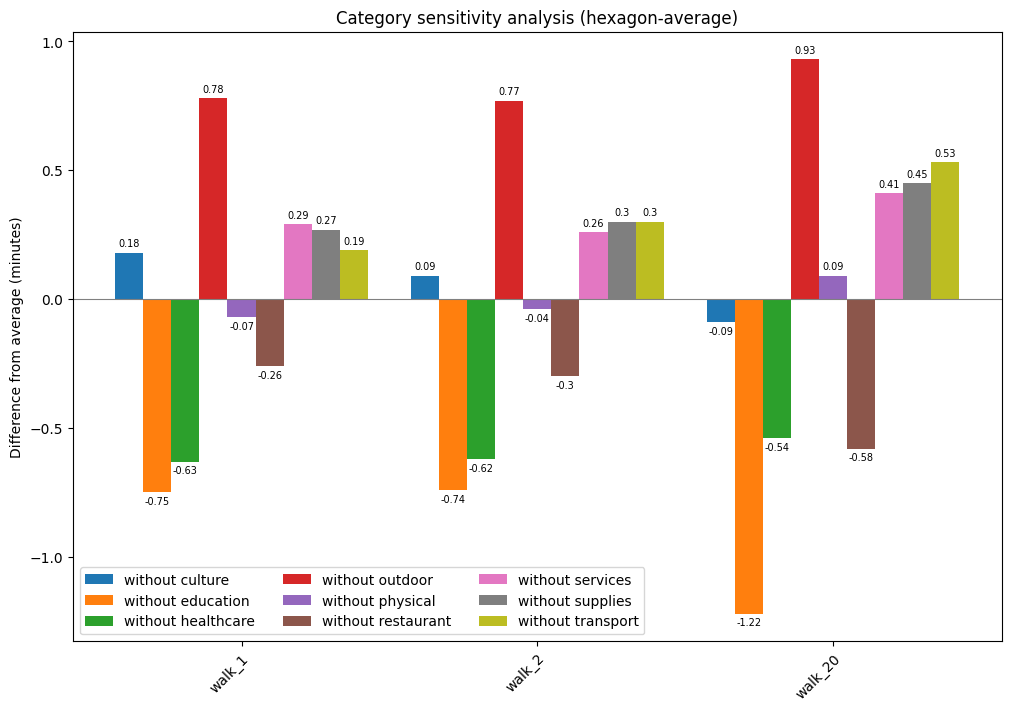

In [45]:
average_baseline = {
    config: gdf_cat[config].apply(lambda x: np.mean(list(x.values())) if isinstance(x, dict) else x).mean()
    for config in configurations
}

n_s = {
    f"without_{category}": [
        round(gdf_cat[f"{configuration}_without_{category}"].mean() - average_baseline[configuration], 2)
        for configuration in configurations
    ]
    for category in categories
}

x = np.arange(len(configurations)) * 2  # group positions, spaced to fit wider bars
width = 0.19
group_centers = x + width * (len(categories) - 1) / 2

fig, ax = plt.subplots(layout='constrained', figsize=(10, 7))

for i, (attribute, measurement) in enumerate(n_s.items()):
    offset = width * i
    rects = ax.bar(x + offset, measurement, width, label=attribute.replace("_", " "))
    ax.bar_label(rects, padding=3, fontsize=7)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='-')


ax.set_ylabel('Difference from average (minutes)')
ax.set_title('Category sensitivity analysis (hexagon-average)')
ax.set_xticks(group_centers, [c.replace("average_time_", "") for c in configurations], rotation=45, ha="right", rotation_mode="anchor")
ax.legend(loc='lower left', ncols=3)

plt.show()

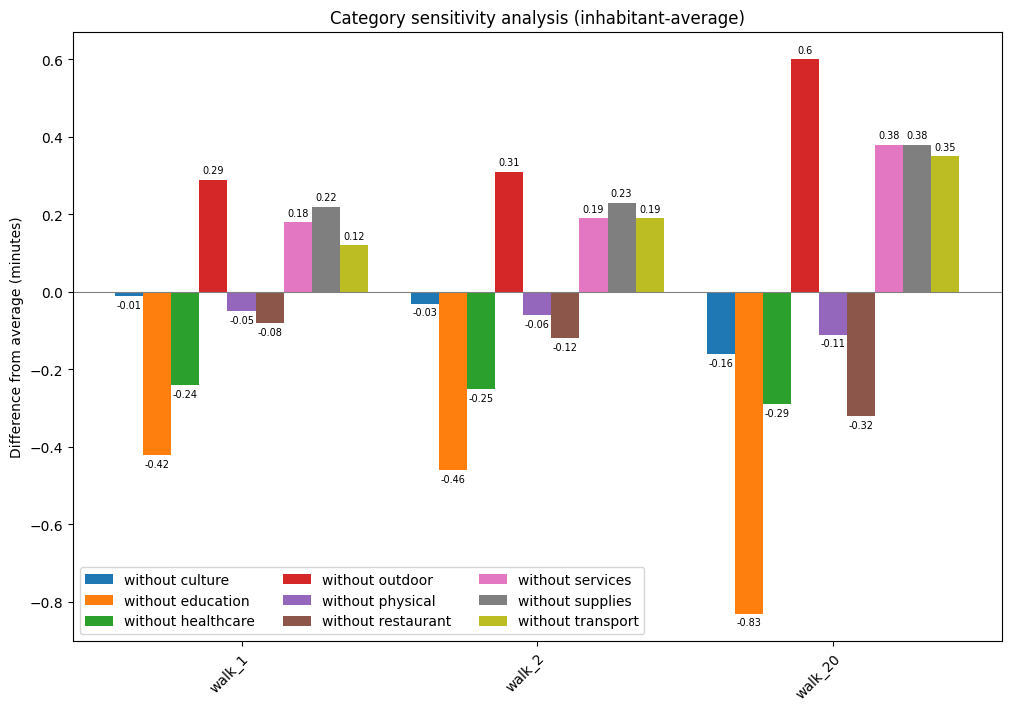

{'culture': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), 'education': (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), 'healthcare': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), 'outdoor': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0), 'physical': (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0), 'restaurant': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0), 'services': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902, 1.0), 'supplies': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0), 'transport': (0.7372549019607844, 0.7411764705882353, 0.13333333333333333, 1.0)}


In [46]:
average_baseline = {
    config: np.average(gdf_cat[config].apply(lambda x: np.mean(list(x.values())) if isinstance(x, dict) else x), weights=gdf_cat["population"])
    for config in configurations
}


n_s = {
    f"without_{category}": [
        round(np.average(gdf_cat[f"{configuration}_without_{category}"], weights=gdf_cat["population"]) - average_baseline[configuration], 2)
        for configuration in configurations
    ]
    for category in categories
}

x = np.arange(len(configurations)) * 2  # group positions, spaced to fit wider bars
width = 0.19
group_centers = x + width * (len(categories) - 1) / 2

fig, ax = plt.subplots(layout='constrained', figsize=(10, 7))

for i, (attribute, measurement) in enumerate(n_s.items()):
    offset = width * i
    rects = ax.bar(x + offset, measurement, width, label=attribute.replace("_", " "))
    ax.bar_label(rects, padding=3, fontsize=7)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='-')


ax.set_ylabel('Difference from average (minutes)')
ax.set_title('Category sensitivity analysis (inhabitant-average)')
ax.set_xticks(group_centers, [c.replace("average_time_", "") for c in configurations], rotation=45, ha="right", rotation_mode="anchor")
ax.legend(loc='lower left', ncols=3)


plt.show()

color_category_mapping = {}
handles, labels = ax.get_legend_handles_labels()
for handle, label in zip(handles, labels):
    color = handle.patches[0].get_facecolor()
    color_category_mapping[label.replace("without ", "")] = color

print(color_category_mapping)

### Number of items per category

<Axes: title={'center': 'Count of OSM features by category'}, xlabel='category'>

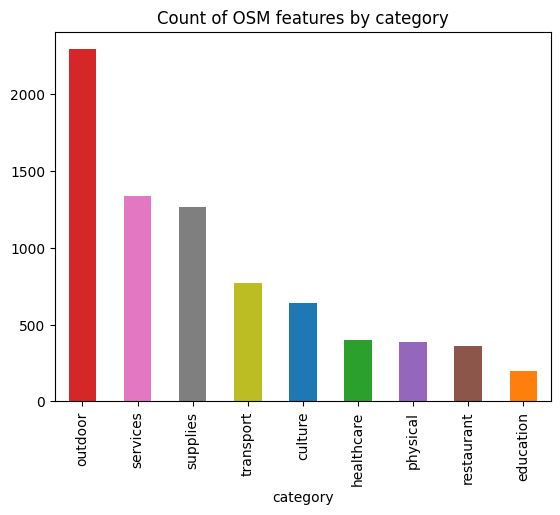

In [47]:
categories_value_counts = gpd.read_parquet("data/osm_features/bamberg_osm_features.parquet")["category"].value_counts()
categories_value_counts.plot(kind="bar", legend=False, title="Count of OSM features by category", color=[color_category_mapping.get(category, (0.1, 0.1, 0.1)) for category in categories_value_counts.index])

<Axes: >

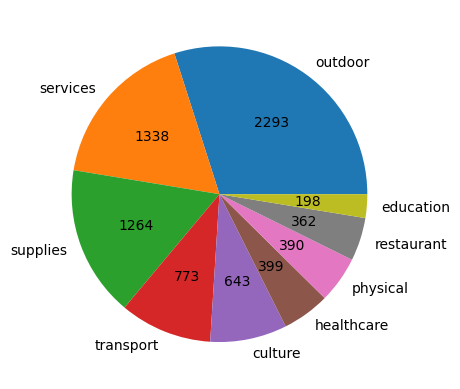

In [48]:
categories_value_counts.plot(kind="pie", autopct=lambda x: f"{round(x * categories_value_counts.sum() / 100)}", color=[color_category_mapping.get(category, (0.1, 0.1, 0.1)) for category in categories_value_counts.index])

In [49]:
len(gpd.read_parquet("data/osm_features/bamberg_osm_features.parquet"))

7660